対象CSV数: 512
[1/512] 読み込み: 001_DMC_delorean_last90d_usd.csv
  採用 len: 2162
[2/512] 読み込み: 001_GIRAFFES_the-giraffes_last90d_usd.csv
  採用 len: 408
[3/512] 読み込み: 001_HELIX_helix-2_last90d_usd.csv
  採用 len: 797
[4/512] 読み込み: 001_霞_mist-2_last90d_usd.csv
  採用 len: 1273
[5/512] 読み込み: 002_ESIM_depinsim_last90d_usd.csv
  採用 len: 1502
[6/512] 読み込み: 002_REKT_rekt-04bbe51a-e290-450a-afb5-b2b43b80b20e_last90d_usd.csv
  採用 len: 700
[7/512] 読み込み: 003_ALA_alanyaspor-fan-token_last90d_usd.csv
  採用 len: 2161
[8/512] 読み込み: 003_USDCX_usdcx-stacks_last90d_usd.csv
  採用 len: 623
[9/512] 読み込み: 004_FROG_froggy-2_last90d_usd.csv
  採用 len: 2162
[10/512] 読み込み: 004_RWA_xend-finance_last90d_usd.csv
  採用 len: 2161
[11/512] 読み込み: 005_ECHO_echo-protocol_last90d_usd.csv
  採用 len: 2161
[12/512] 読み込み: 005_GAK_gakster_last90d_usd.csv
  採用 len: 2144
[13/512] 読み込み: 006_TANGO_contango_last90d_usd.csv
  採用 len: 1868
[14/512] 読み込み: 006_USDT0_usdt0_last90d_usd.csv
  採用 len: 2162
[15/512] 読み込み: 007_CONET_conet-network_last90d_us

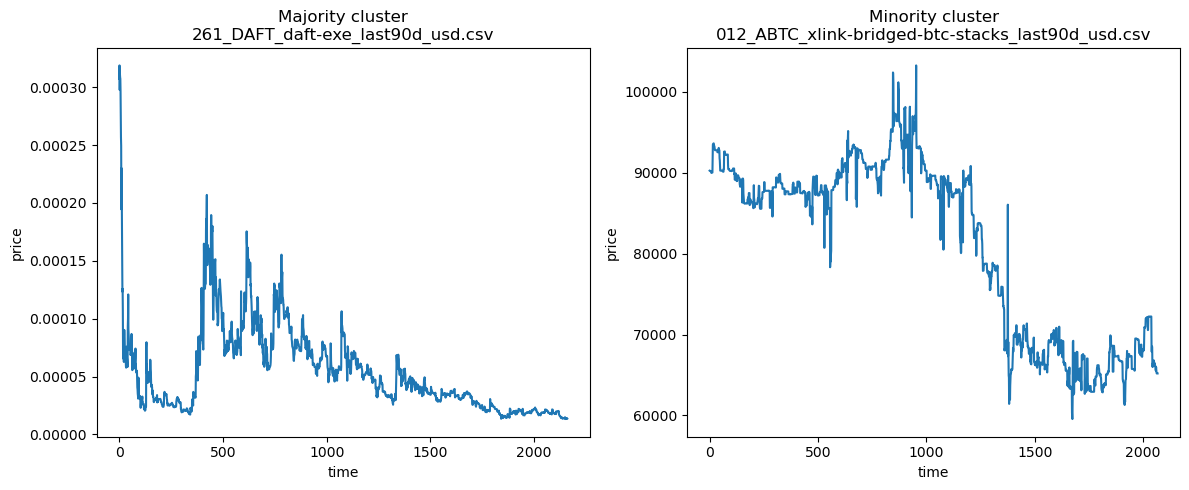


クラスタ一覧
                                                                                name  cluster
                                                    001_DMC_delorean_last90d_usd.csv        0
                                           001_GIRAFFES_the-giraffes_last90d_usd.csv        0
                                                   001_HELIX_helix-2_last90d_usd.csv        0
                                                        001_霞_mist-2_last90d_usd.csv        0
                                                   002_ESIM_depinsim_last90d_usd.csv        0
                  002_REKT_rekt-04bbe51a-e290-450a-afb5-b2b43b80b20e_last90d_usd.csv        0
                                        003_ALA_alanyaspor-fan-token_last90d_usd.csv        0
                                              003_USDCX_usdcx-stacks_last90d_usd.csv        0
                                                   004_FROG_froggy-2_last90d_usd.csv        0
                                                004_

In [6]:
import pandas as pd
import numpy as np
import glob
import os
import random
import matplotlib.pyplot as plt
from collections import Counter
from tslearn.clustering import TimeSeriesKMeans

# ==========================
# 設定
# ==========================
path = r"D:\musashino-university\finance\cc\*.csv"
n_clusters = 3
random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)

# ==========================
# CSV読み込み
# ==========================
files = glob.glob(path)
total_files = len(files)

print("対象CSV数:", total_files)

dfs = {}

for i, f in enumerate(files, start=1):

    name = os.path.basename(f)

    print(f"[{i}/{total_files}] 読み込み:", name)

    try:
        df = pd.read_csv(f)
    except Exception as e:
        print("  読み込み失敗:", e)
        continue

    if "price" not in df.columns:
        print("  price列なし")
        continue

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["price"]).reset_index(drop=True)

    if len(df) > 10:
        dfs[name] = df
        print("  採用 len:", len(df))
    else:
        print("  スキップ")

print("series count:", len(dfs))

if len(dfs) < n_clusters:
    raise ValueError("クラスタ数より系列が少ないです")

# ==========================
# 時系列配列作成
# ==========================
names = list(dfs.keys())

min_len = min(len(df["price"]) for df in dfs.values())

print("共通長:", min_len)

series_list = []

for name in names:

    print("series:", name)

    series_list.append(dfs[name]["price"].values[:min_len])

X = np.array(series_list, dtype=float)

# tslearn用
X = X[:, :, np.newaxis]

print("X shape:", X.shape)

# ==========================
# クラスタリング
# ==========================
print("クラスタリング開始")

model = TimeSeriesKMeans(
    n_clusters=n_clusters,
    metric="dtw",
    max_iter=20,
    random_state=random_seed
)

labels = model.fit_predict(X)

print("labels:", labels)

# ==========================
# クラスタ数
# ==========================
cluster_counts = Counter(labels)

print("cluster counts:")
for k, v in cluster_counts.items():
    print("cluster", k, ":", v)

# ==========================
# 最大クラスタ
# ==========================
majority_cluster = max(cluster_counts, key=cluster_counts.get)

majority_idx = np.where(labels == majority_cluster)[0]
majority_names = [names[i] for i in majority_idx]

print("最大クラスタ:", majority_cluster)

# ランダム1個選択
majority_pick = random.choice(majority_names)

print("最大クラスタ表示:", majority_pick)

# ==========================
# 最小クラスタ
# ==========================
minority_cluster = min(cluster_counts, key=cluster_counts.get)

minority_idx = np.where(labels == minority_cluster)[0]
minority_names = [names[i] for i in minority_idx]

print("最小クラスタ:", minority_cluster)

minority_pick = minority_names[0]

print("最小クラスタ表示:", minority_pick)

# ==========================
# 2列プロット（横並び）
# ==========================
print("プロット作成")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --------------------------
# 左：最大クラスタ
# --------------------------
y = dfs[majority_pick]["price"].values

axes[0].plot(y)

axes[0].set_title(f"Majority cluster\n{majority_pick}")
axes[0].set_xlabel("time")
axes[0].set_ylabel("price")

# --------------------------
# 右：最小クラスタ
# --------------------------
y = dfs[minority_pick]["price"].values

axes[1].plot(y)

axes[1].set_title(f"Minority cluster\n{minority_pick}")
axes[1].set_xlabel("time")
axes[1].set_ylabel("price")

plt.tight_layout()
plt.show()

# ==========================
# クラスタ一覧
# ==========================
result_df = pd.DataFrame({
    "name": names,
    "cluster": labels
})

print("\nクラスタ一覧")
print(result_df.sort_values(["cluster","name"]).to_string(index=False))